# 01. Исследование данных

**Цель:** описать train и определить направления для признаков.
**Условия:** суммы сравниваются внутри валюты; счёт — пара «банк–счёт». Совпадающие строки сохраняются.

[Итоговый отчёт](../reports/full/RESULTS.md)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "pyproject.toml").exists() and (p / "notebooks").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Запустите notebook из корня проекта или notebooks")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from aml.pipeline import TARGET, load_raw, temporal_slices
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
raw = load_raw(PROJECT_ROOT)
periods = temporal_slices(raw["Timestamp"])
df = raw.iloc[periods["train"]].copy()
del raw
print("TRAIN only:", df.shape, df.Timestamp.min(), df.Timestamp.max())
display(df.isna().sum().to_frame("missing"))
print("Identical rows (retained):", int(df.duplicated().sum()))
display(df[TARGET].value_counts().reindex([0, 1], fill_value=0).to_frame("count"))
print("Positive prevalence / random-ranking AP:", df[TARGET].mean())

TRAIN only: (4846503, 11) 2022-09-01 00:00:00 2022-09-07 14:47:00


,missing
Timestamp,0
From Bank,0
Account,0
To Bank,0
Account.1,0
Receiving Currency,0
Payment Currency,0
Payment Format,0
Amount Paid,0
Amount Received,0


Identical rows (retained): 0


,count
Is Laundering,
0,4844272
1,2231


Positive prevalence / random-ranking AP: 0.0004603319135467367


## Временная активность

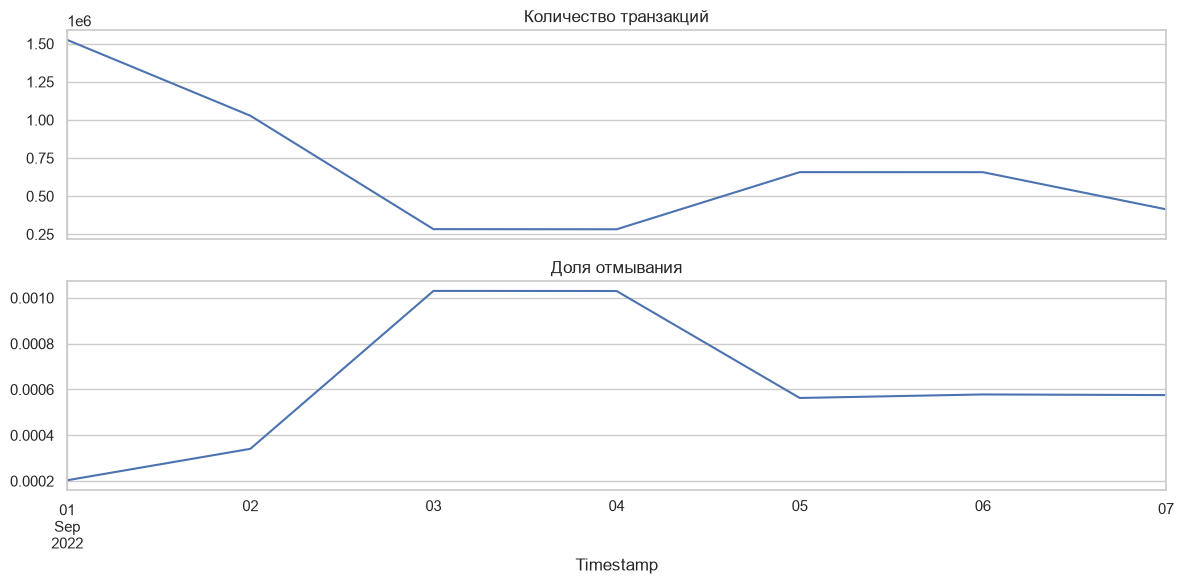

,size,sum,mean
Timestamp,,,
0,735340,84,0.000114
1,190359,71,0.000373
2,188224,78,0.000414
3,189434,88,0.000465
4,188831,91,0.000482
5,188610,91,0.000482
6,190324,86,0.000452
7,188153,97,0.000516
8,188511,91,0.000483


In [3]:
daily = df.groupby(df.Timestamp.dt.floor("D"))[TARGET].agg(["size", "sum", "mean"])
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
daily["size"].plot(ax=axes[0], title="Количество транзакций")
daily["mean"].plot(ax=axes[1], title="Доля отмывания")
plt.tight_layout(); plt.show()
hourly = df.groupby(df.Timestamp.dt.hour)[TARGET].agg(["size", "sum", "mean"])
display(hourly)

## Валюты, форматы и суммы

,size,sum,mean
Payment Currency,,,
US Dollar,1787808,868,0.000486
Euro,1118092,637,0.000570
Yuan,338746,124,0.000366
Rupee,237931,71,0.000298
Bitcoin,215979,80,0.000370
Saudi Riyal,180584,76,0.000421
Yen,147644,65,0.000440
Australian Dollar,147253,51,0.000346
Brazil Real,140082,51,0.000364


,size,sum,mean
Payment Format,,,
Cheque,1668690,292,0.000175
Credit Card,1188115,174,0.000146
Reinvestment,650458,0,0.000000
ACH,531100,1595,0.003003
Cash,437598,90,0.000206
Bitcoin,215952,80,0.000370
Wire,154590,0,0.000000


,count,mean,std,min,25%,50%,75%,max
Payment Currency,,,,,,,,
Australian Dollar,147253.0,4.737791e+05,1.431586e+07,0.010000,206.390000,1294.880000,8124.310000,2.650864e+09
Bitcoin,215979.0,3.335240e+01,1.835300e+03,0.000001,0.011961,0.077343,0.497425,6.160250e+05
Brazil Real,140082.0,2.047623e+06,5.235094e+07,0.010000,878.200000,5583.100000,34625.450000,7.890341e+09
Canadian Dollar,123061.0,4.851634e+05,1.748829e+07,0.010000,203.410000,1253.040000,7880.150000,2.709593e+09
Euro,1118092.0,2.856249e+05,1.072175e+07,0.010000,130.410000,809.300000,4949.585000,4.714115e+09
Mexican Peso,59136.0,1.084549e+07,8.731857e+08,0.010000,3070.242500,19278.360000,123143.430000,1.503626e+11
Ruble,61995.0,3.104396e+07,8.592144e+08,0.010000,11155.470000,72573.770000,435293.040000,8.698050e+10
Rupee,237931.0,3.382969e+07,2.219690e+09,0.010000,10453.510000,66094.100000,451539.380000,8.623400e+11
Saudi Riyal,180584.0,1.336704e+06,5.501826e+07,0.010000,579.030000,3653.870000,23042.500000,1.513349e+10


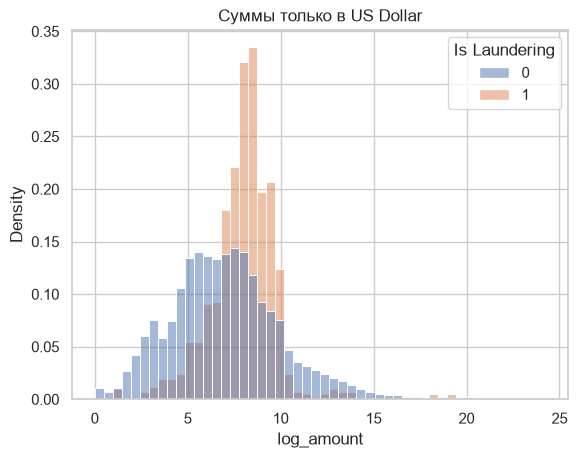

In [4]:
for col in ["Payment Currency", "Payment Format"]:
    display(df.groupby(col, observed=True)[TARGET].agg(["size", "sum", "mean"]).sort_values("size", ascending=False))
display(df.groupby("Payment Currency", observed=True)["Amount Paid"].describe())
main_currency = df["Payment Currency"].value_counts().index[0]
plot_df = df.loc[df["Payment Currency"].eq(main_currency), ["Amount Paid", TARGET]].copy()
plot_df["log_amount"] = np.log1p(plot_df["Amount Paid"])
sns.histplot(data=plot_df, x="log_amount", hue=TARGET, bins=50, stat="density", common_norm=False)
plt.title(f"Суммы только в {main_currency}"); plt.show()

## Счета и числовые связи

Sender bank-account pairs: 677078
Receiver bank-account pairs: 575193


count    677078.000000
mean          7.157969
std         222.540622
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max      148694.000000
dtype: float64

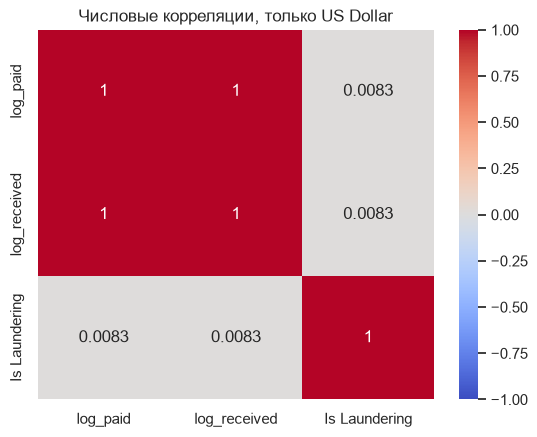

In [5]:
print("Sender bank-account pairs:", df[["From Bank", "Account"]].drop_duplicates().shape[0])
print("Receiver bank-account pairs:", df[["To Bank", "Account.1"]].drop_duplicates().shape[0])
activity = df.groupby(["From Bank", "Account"]).size()
display(activity.describe())
# Pearson по category codes бессмысленен: коды не задают расстояние между категориями.
numeric = pd.DataFrame({"log_paid": np.log1p(df["Amount Paid"]),
                        "log_received": np.log1p(df["Amount Received"]), TARGET: df[TARGET]})
numeric = numeric.loc[df["Payment Currency"].eq(main_currency) & df["Receiving Currency"].eq(main_currency)]
sns.heatmap(numeric.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm")
plt.title(f"Числовые корреляции, только {main_currency}"); plt.show()

## Выводы

- Положительных 0,046%: качество оцениваем по AP и recall, а не accuracy.
- На ACH приходится 1595 из 2231 положительных в train; формат платежа — полезный кандидат в признаки.
- Разброс сумм и активности мотивирует log-преобразования и исторические счётчики. Закономерности train требуют проверки на будущих периодах.